In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

## A. Load & Understand

In [30]:
df = pd.read_csv("food_delivery_dataset.csv")
TIME = "Time_taken (min)"
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [31]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'distance_km', 'delivery_speed'],
      dtype='str')

In [32]:
print("Data types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Data types:
 ID                                 str
Delivery_person_ID                 str
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weather_conditions                 str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries            float64
Festival                           str
City                               str
Time_taken (min)                 int64
distance_km                    float64
delivery_speed                     str
dtype: object

Missing values:
 ID                                0
Delivery_person_ID                0
Delivery_person_Age      

In [33]:
for c in ["Weather_conditions", "Road_traffic_density", "multiple_deliveries", "Festival", "City"]:
    print(c, "->", df[c].astype(str).str.strip().unique()[:10])

Weather_conditions -> <StringArray>
['Fog', 'Stormy', 'Sandstorms', 'Windy', 'Cloudy', 'Sunny']
Length: 6, dtype: str
Road_traffic_density -> <StringArray>
['Jam', 'High', 'Medium', 'Low']
Length: 4, dtype: str
multiple_deliveries -> <StringArray>
['3.0', '1.0', '0.0', '2.0']
Length: 4, dtype: str
Festival -> <StringArray>
['No', 'Yes']
Length: 2, dtype: str
City -> <StringArray>
['Metropolitian', 'Urban', 'Semi-Urban']
Length: 3, dtype: str


## B. Clean the Data
Decisions (also documented in README.md):
1. Drop exact duplicate rows.
2. Strip whitespace and convert placeholder strings (`"NaN"`) to real missing values.
3. Remove label prefixes (`conditions Sunny` → `Sunny`, `(min) 24` → `24`).
4. Convert age, ratings, multiple deliveries and delivery time to numbers; parse `Order_Date`.
5. Remove invalid rows: ratings outside 1–5, ages outside 18–65, distance ≤ 0, time ≤ 0.
6. Fill missing age/ratings with the **median** (robust to outliers) and categorical gaps with the **mode**; missing `multiple_deliveries` = 0.
7. `Time_Orderd` (not needed for the questions) is kept as is, not dropped.

In [34]:
df = df.drop_duplicates().copy()

# 2. whitespace + placeholder strings
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype(str).str.strip().replace({"NaN": np.nan, "nan": np.nan, "None": np.nan})

# 3. prefixes
df["Weather_conditions"] = df["Weather_conditions"].str.replace("conditions ", "", regex=False)
df[TIME] = df[TIME].astype(str).str.replace(r"\(min\)\s*", "", regex=True)

# 4. types
for c in ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries", TIME, "distance_km"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True, errors="coerce")

# 5. invalid values
before = len(df)
df = df[df["Delivery_person_Ratings"].between(1, 5) | df["Delivery_person_Ratings"].isna()]
df = df[df["Delivery_person_Age"].between(18, 65) | df["Delivery_person_Age"].isna()]
df = df[(df["distance_km"] > 0) & (df[TIME] > 0)]
print("Invalid rows removed:", before - len(df))

# 6. missing values
for c in ["Delivery_person_Age", "Delivery_person_Ratings"]:
    df[c] = df[c].fillna(df[c].median())
for c in ["Weather_conditions", "Road_traffic_density", "City", "Festival"]:
    df[c] = df[c].fillna(df[c].mode()[0])
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(0)
df = df.dropna(subset=[TIME, "distance_km"])

# Delivery speed in km/h (recomputed so it is always consistent)
df["delivery_speed"] = df["distance_km"] / (df[TIME] / 60)

print("Clean shape:", df.shape)
print("Remaining missing (Time_Orderd is intentionally kept):\n", df.isnull().sum()[lambda s: s > 0])

/var/folders/ph/cd_7d8m92k1_l1q4_bhjxg300000gn/T/ipykernel_17862/1351863205.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include="object").columns:


Invalid rows removed: 0
Clean shape: (38964, 22)
Remaining missing (Time_Orderd is intentionally kept):
 Time_Orderd    835
dtype: int64


## C. Basic Analysis

In [35]:
stats = {
    "total_deliveries": int(len(df)),
    "avg_delivery_time_min": float(round(df[TIME].mean(), 2)),
    "min_delivery_time_min": float(df[TIME].min()),
    "max_delivery_time_min": float(df[TIME].max()),
    "avg_distance_km": float(round(df["distance_km"].mean(), 2)),
    "avg_speed_kmh": float(round(df["delivery_speed"].mean(), 2)),
    "avg_rating": float(round(df["Delivery_person_Ratings"].mean(), 2)),
    "avg_age": float(round(df["Delivery_person_Age"].mean(), 1)),
}
pd.Series(stats)

total_deliveries         38964.00
avg_delivery_time_min       26.58
min_delivery_time_min       10.00
max_delivery_time_min       54.00
avg_distance_km              9.77
avg_speed_kmh               23.59
avg_rating                   4.63
avg_age                     29.60
dtype: float64

## D. Competition Questions (all computed programmatically)

In [36]:
# Q1 - Traffic impact
traffic = df.groupby("Road_traffic_density")[TIME].mean().round(2).sort_values(ascending=False)
print(traffic)
print(f"\nQ1 ANSWER: '{traffic.idxmax()}' traffic has the highest average delivery time ({traffic.max():.2f} min).")

Road_traffic_density
Jam       31.44
High      27.41
Medium    26.93
Low       21.50
Name: Time_taken (min), dtype: float64

Q1 ANSWER: 'Jam' traffic has the highest average delivery time (31.44 min).


In [37]:
# Q2 - Distance impact
corr = df["distance_km"].corr(df[TIME])
slope, intercept = np.polyfit(df["distance_km"], df[TIME], 1)

df["distance_band"] = pd.cut(df["distance_km"], bins=[0, 5, 10, 15, 20, 25, np.inf],
                             labels=["0-5", "5-10", "10-15", "15-20", "20-25", "25+"])
band = df.groupby("distance_band", observed=True)[TIME].agg(["count", "mean"]).round(2)
print(band)
print(f"\nCorrelation (distance vs time): {corr:.3f}")
print(f"Linear trend: each extra km adds about {slope:.2f} min (intercept {intercept:.2f} min)")
direction = "increases" if corr > 0 else "decreases"
strength = "strongly" if abs(corr) > 0.5 else "moderately" if abs(corr) > 0.3 else "weakly"
print(f"\nQ2 ANSWER: Delivery time {direction} with distance ({strength}, r={corr:.2f}).")

               count   mean
distance_band              
0-5            10390  22.42
5-10           10445  24.64
10-15          10567  30.09
15-20           5881  30.07
20-25           1681  30.08

Correlation (distance vs time): 0.322
Linear trend: each extra km adds about 0.54 min (intercept 21.35 min)

Q2 ANSWER: Delivery time increases with distance (moderately, r=0.32).


In [38]:
# Q3 - Weather x traffic
combo = (df.groupby(["Weather_conditions", "Road_traffic_density"])[TIME]
           .agg(["count", "mean"]).round(2).sort_values("mean", ascending=False))
display(combo.head(10))
(w, t), row = combo.iloc[0].name, combo.iloc[0]
print(f"Q3 ANSWER: {w} weather + {t} traffic has the highest average delivery time ({row['mean']:.2f} min, n={int(row['count'])}).")

count   mean
Weather_conditions Road_traffic_density              
Fog                Jam                    2162  36.89
Cloudy             Jam                    2080  36.71
Windy              Jam                    2081  30.40
Sandstorms         Jam                    2095  30.25
Stormy             Jam                    2032  30.20
Cloudy             High                    651  28.93
                   Medium                 1595  28.84
Fog                High                    671  28.51
                   Medium                 1615  28.47
Sandstorms         High                    604  28.02

Q3 ANSWER: Fog weather + Jam traffic has the highest average delivery time (36.89 min, n=2162).


## E. Visualizations

/var/folders/ph/cd_7d8m92k1_l1q4_bhjxg300000gn/T/ipykernel_17862/3271976663.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=traffic.loc[order].index, y=traffic.loc[order].values, palette="viridis")


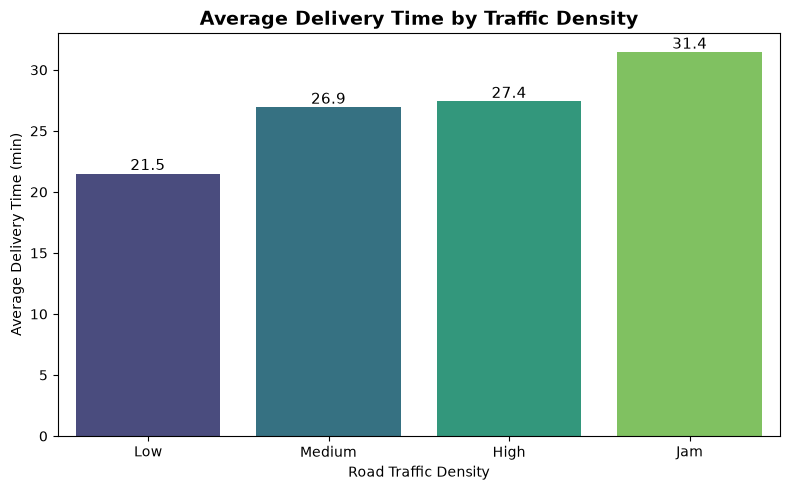

In [39]:
# Chart 1 - avg delivery time by traffic density
order = ["Low", "Medium", "High", "Jam"]
order = [o for o in order if o in traffic.index] + [o for o in traffic.index if o not in order]
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=traffic.loc[order].index, y=traffic.loc[order].values, palette="viridis")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.title("Average Delivery Time by Traffic Density", fontsize=14, weight="bold")
plt.xlabel("Road Traffic Density"); plt.ylabel("Average Delivery Time (min)")
plt.tight_layout(); plt.savefig("charts/chart1_traffic_vs_time.png", dpi=150); plt.show()

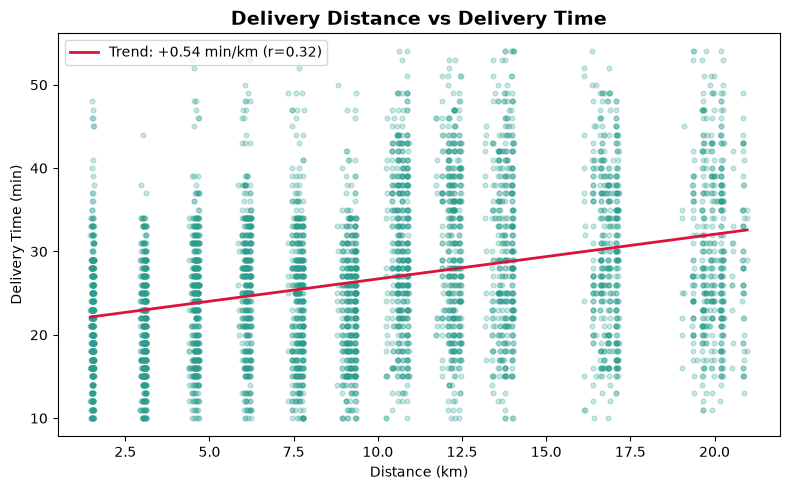

In [40]:
# Chart 2 - distance vs delivery time
sample = df.sample(min(5000, len(df)), random_state=42)
plt.figure(figsize=(8, 5))
plt.scatter(sample["distance_km"], sample[TIME], alpha=0.25, s=12, color="#2a9d8f")
xs = np.linspace(df["distance_km"].min(), df["distance_km"].max(), 100)
plt.plot(xs, slope * xs + intercept, color="crimson", lw=2, label=f"Trend: +{slope:.2f} min/km (r={corr:.2f})")
plt.title("Delivery Distance vs Delivery Time", fontsize=14, weight="bold")
plt.xlabel("Distance (km)"); plt.ylabel("Delivery Time (min)"); plt.legend()
plt.tight_layout(); plt.savefig("charts/chart2_distance_vs_time.png", dpi=150); plt.show()

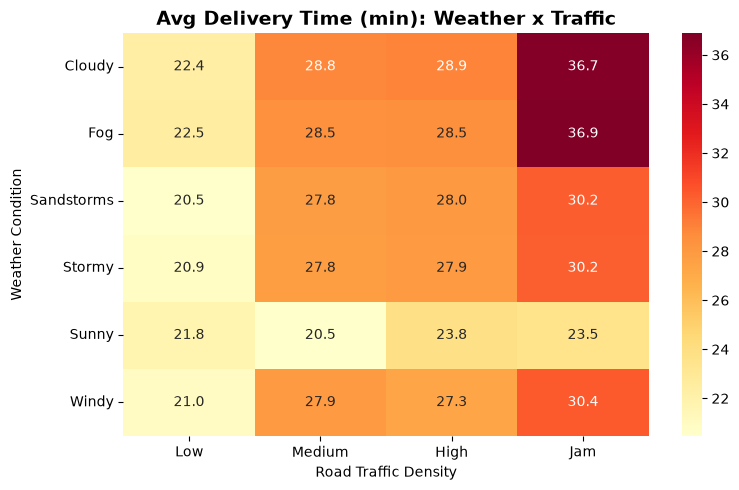

In [41]:
# Chart 3 (bonus) - weather x traffic heatmap
pivot = df.pivot_table(index="Weather_conditions", columns="Road_traffic_density", values=TIME, aggfunc="mean")
pivot = pivot[[c for c in order if c in pivot.columns]]
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Avg Delivery Time (min): Weather x Traffic", fontsize=14, weight="bold")
plt.xlabel("Road Traffic Density"); plt.ylabel("Weather Condition")
plt.tight_layout(); plt.savefig("charts/chart3_weather_traffic_heatmap.png", dpi=150); plt.show()

/var/folders/ph/cd_7d8m92k1_l1q4_bhjxg300000gn/T/ipykernel_17862/2610280072.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=m.index, y=m.values, ax=ax, palette="mako")
/var/folders/ph/cd_7d8m92k1_l1q4_bhjxg300000gn/T/ipykernel_17862/2610280072.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=m.index, y=m.values, ax=ax, palette="mako")


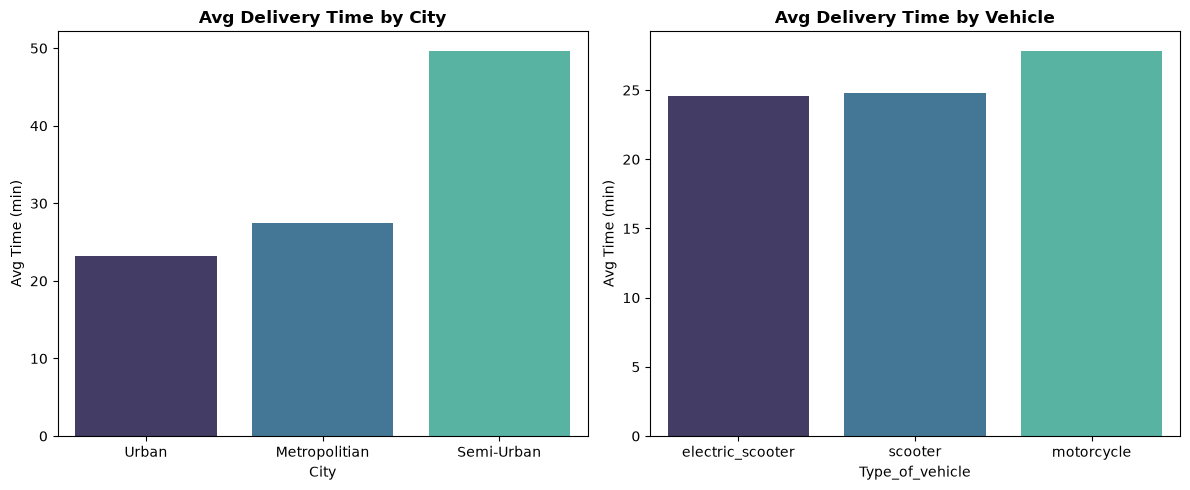

In [42]:
# Chart 4 (bonus) - city and vehicle comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in [(axes[0], "City", "Avg Delivery Time by City"),
                       (axes[1], "Type_of_vehicle", "Avg Delivery Time by Vehicle")]:
    m = df.groupby(col)[TIME].mean().sort_values()
    sns.barplot(x=m.index, y=m.values, ax=ax, palette="mako")
    ax.set_title(title, weight="bold"); ax.set_xlabel(col); ax.set_ylabel("Avg Time (min)")
plt.tight_layout(); plt.savefig("charts/chart4_city_vehicle.png", dpi=150); plt.show()

## F. Business Insights (data-driven)

In [43]:
city = df.groupby("City")[TIME].mean().round(2)
multi = df.groupby("multiple_deliveries")[TIME].mean().round(2)
vehicle = df.groupby("Type_of_vehicle")[TIME].mean().round(2)
fest = df.groupby("Festival")[TIME].mean().round(2)
rating_corr = df["Delivery_person_Ratings"].corr(df[TIME])
base = df[TIME].mean()

insights = [
    f"1. Traffic: '{traffic.idxmax()}' traffic averages {traffic.max():.1f} min vs {traffic.min():.1f} min in "
    f"'{traffic.idxmin()}' traffic ({(traffic.max()/traffic.min()-1)*100:.0f}% slower). "
    "Business meaning: add dynamic ETAs, route around congestion and shift staffing to peak-traffic zones.",
    f"2. Distance: each extra km adds about {slope:.2f} min (r={corr:.2f}). "
    "Business meaning: price delivery fees by distance band and limit the radius of very long orders to protect delivery promises.",
    f"3. Weather x traffic: '{w}' + '{t}' is the worst combination at {row['mean']:.1f} min "
    f"({(row['mean']/base-1)*100:.0f}% above the overall average of {base:.1f} min). "
    "Business meaning: add surge incentives or extend ETAs in this situation.",
    f"4. City type: '{city.idxmax()}' is slowest ({city.max():.1f} min) and '{city.idxmin()}' fastest ({city.min():.1f} min). "
    "Business meaning: allocate more riders or review restaurant hubs in the slower city type.",
    f"5. Workload: orders with {int(multi.idxmax())} simultaneous deliveries take {multi.max():.1f} min vs {multi.min():.1f} min at the lowest level. "
    "Business meaning: cap batched deliveries per rider to keep delivery times predictable.",
]
for i in insights:
    print(i, "\n")

1. Traffic: 'Jam' traffic averages 31.4 min vs 21.5 min in 'Low' traffic (46% slower). Business meaning: add dynamic ETAs, route around congestion and shift staffing to peak-traffic zones. 

2. Distance: each extra km adds about 0.54 min (r=0.32). Business meaning: price delivery fees by distance band and limit the radius of very long orders to protect delivery promises. 

3. Weather x traffic: 'Fog' + 'Jam' is the worst combination at 36.9 min (39% above the overall average of 26.6 min). Business meaning: add surge incentives or extend ETAs in this situation. 

4. City type: 'Semi-Urban' is slowest (49.7 min) and 'Urban' fastest (23.2 min). Business meaning: allocate more riders or review restaurant hubs in the slower city type. 

5. Workload: orders with 3 simultaneous deliveries take 47.9 min vs 23.2 min at the lowest level. Business meaning: cap batched deliveries per rider to keep delivery times predictable. 



## G. AI-Powered Explanation
Pandas computed everything above. The LLM only receives those results and writes a business summary.

The API key is read from the environment (never hard-coded). Set it before running:
- Mac/Linux: `export GROQ_API_KEY="your_key"`
- Windows (PowerShell): `$env:GROQ_API_KEY="your_key"`
- Or place `GROQ_API_KEY=your_key` in a local `.env` file (listed in `.gitignore`).
- In Colab you can also use `os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")`.

In [44]:
#Only run if you are using colab, you can skip this if you are not using colab
import os
try:
    from google.colab import userdata
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
except Exception:
    pass  # not in Colab, fall back to an environment variable or .env

In [45]:
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

summary = {
    "basic_stats": stats,
    "Q1_avg_time_by_traffic": traffic.to_dict(),
    "Q2_distance": {"correlation": round(corr, 3), "min_added_per_km": round(slope, 2),
                    "avg_time_by_distance_band": band["mean"].to_dict()},
    "Q3_worst_combination": {"weather": w, "traffic": t, "avg_time": float(row["mean"])},
    "avg_time_by_city": city.to_dict(),
    "avg_time_by_multiple_deliveries": {str(k): v for k, v in multi.to_dict().items()},
}
prompt = ("You are a business analyst for a food-delivery company. Using ONLY the numbers below, write a short, "
          "clear explanation (max 200 words) for a non-technical manager: what is slowing deliveries and "
          "3 concrete recommendations.\n\nRESULTS:\n" + str(summary))

api_key = os.getenv("GROQ_API_KEY")
if not api_key:
    print("GROQ_API_KEY not set. Set it and re-run this cell. The prompt that would be sent:\n")
    print(prompt)
else:
    from groq import Groq
    client = Groq(api_key=api_key)
    resp = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
    )
    ai_text = resp.choices[0].message.content
    print(ai_text)
    with open("ai_explanation.txt", "w") as f:
        f.write(ai_text)

GROQ_API_KEY not set. Set it and re-run this cell. The prompt that would be sent:

You are a business analyst for a food-delivery company. Using ONLY the numbers below, write a short, clear explanation (max 200 words) for a non-technical manager: what is slowing deliveries and 3 concrete recommendations.

RESULTS:
{'basic_stats': {'total_deliveries': 38964, 'avg_delivery_time_min': 26.58, 'min_delivery_time_min': 10.0, 'max_delivery_time_min': 54.0, 'avg_distance_km': 9.77, 'avg_speed_kmh': 23.59, 'avg_rating': 4.63, 'avg_age': 29.6}, 'Q1_avg_time_by_traffic': {'Jam': 31.44, 'High': 27.41, 'Medium': 26.93, 'Low': 21.5}, 'Q2_distance': {'correlation': np.float64(0.322), 'min_added_per_km': np.float64(0.54), 'avg_time_by_distance_band': {'0-5': 22.42, '5-10': 24.64, '10-15': 30.09, '15-20': 30.07, '20-25': 30.08}}, 'Q3_worst_combination': {'weather': 'Fog', 'traffic': 'Jam', 'avg_time': 36.89}, 'avg_time_by_city': {'Metropolitian': 27.45, 'Semi-Urban': 49.69, 'Urban': 23.24}, 'avg_time_b

## H. Bonus: Machine Learning Predicting Delivery Time
Machine learning is **not required** by the challenge. This section is an optional extension: it builds a regression model that predicts `Time_taken (min)` from order, rider and condition features, and shows which factors matter most. All Pandas analysis above remains the primary analysis.

**Steps:** feature engineering → encoding → train/test split → model comparison → feature importance → what-if predictions.

**Leakage note:** `delivery_speed` is derived from delivery time, so it is **excluded** from the features.

In [50]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

ml = df.copy()

# Feature engineering from time and date columns
ml["order_hour"] = pd.to_datetime(ml["Time_Orderd"], format="mixed", errors="coerce").dt.hour
ml["order_hour"] = ml["order_hour"].fillna(ml["order_hour"].median())
ml["order_weekday"] = ml["Order_Date"].dt.dayofweek
ml["order_weekday"] = ml["order_weekday"].fillna(ml["order_weekday"].mode()[0])

numeric_cols = [c for c in ["Delivery_person_Age", "Delivery_person_Ratings", "distance_km",
                            "multiple_deliveries", "Vehicle_condition", "order_hour", "order_weekday"]
                if c in ml.columns]
ordinal_cols = ["Road_traffic_density"]                      # has a natural order
nominal_cols = [c for c in ["Weather_conditions", "Type_of_order", "Type_of_vehicle", "Festival", "City"]
                if c in ml.columns]                          # no natural order

features = numeric_cols + ordinal_cols + nominal_cols
X, y = ml[features], ml[TIME]
print("Features used:", features)
print("Target:", TIME, "| rows:", len(X))
print("\nColumns with missing values in X:")
print(X.isnull().sum()[lambda s: s > 0])

Features used: ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km', 'multiple_deliveries', 'Vehicle_condition', 'order_hour', 'order_weekday', 'Road_traffic_density', 'Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
Target: Time_taken (min) | rows: 38964

Columns with missing values in X:
Series([], dtype: int64)


### Encoding categorical variables
Models need numbers, so text columns are encoded:
- **Ordinal encoding** for `Road_traffic_density` (Low < Medium < High < Jam), because the order carries meaning.
- **One-hot encoding** for nominal columns (weather, vehicle, city, ...), because they have no order. Label-encoding these would invent a false ranking.

In [51]:
# Imputers + encoders are fitted on the TRAIN set only (prevents data leakage)
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median", keep_empty_features=True), numeric_cols),
    ("ordinal", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(categories=[traffic_order], handle_unknown="use_encoded_value",
                                  unknown_value=-1))]), ordinal_cols),
    ("onehot", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore"))]), nominal_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (31171, 13) | Test: (7793, 13)


In [52]:
# In the real pipeline, encoders are fitted on the TRAIN set only (prevents data leakage)
preprocess = ColumnTransformer([
    ("ordinal", OrdinalEncoder(categories=[traffic_order], handle_unknown="use_encoded_value",
                               unknown_value=-1), ordinal_cols),
    ("onehot", OneHotEncoder(handle_unknown="ignore"), nominal_cols),
], remainder="passthrough")   # numeric columns pass through unchanged

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (31171, 13) | Test: (7793, 13)


### Train and compare models

In [53]:
models = {
    "Baseline (predict mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, n_jobs=-1, random_state=42),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
}

fitted, rows = {}, []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted[name] = pipe
    rows.append({"Model": name,
                 "MAE (min)": mean_absolute_error(y_test, pred),
                 "RMSE (min)": np.sqrt(mean_squared_error(y_test, pred)),
                 "R2": r2_score(y_test, pred)})

results = pd.DataFrame(rows).set_index("Model").round(3).sort_values("R2", ascending=False)
results

,MAE (min),RMSE (min),R2
Model,,,
Gradient Boosting,3.062,3.816,0.829
Random Forest,3.069,3.858,0.825
Linear Regression,4.749,5.943,0.585
Baseline (predict mean),7.431,9.226,-0.000


In [54]:
best_name = results.index[0]
best = fitted[best_name]
cv = cross_val_score(best, X, y, cv=5, scoring="r2", n_jobs=-1)
print(f"Best model: {best_name}")
print(f"Test MAE: {results.loc[best_name, 'MAE (min)']:.2f} min | Test R2: {results.loc[best_name, 'R2']:.3f}")
print(f"5-fold CV R2: {cv.mean():.3f} (+/- {cv.std():.3f})")

Best model: Gradient Boosting
Test MAE: 3.06 min | Test R2: 0.829
5-fold CV R2: 0.833 (+/- 0.003)


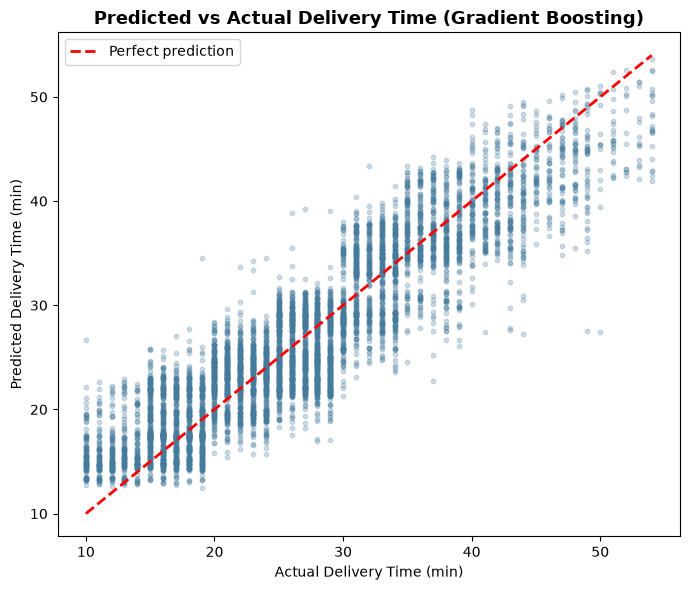

In [55]:
# Chart 5 - predicted vs actual (best model)
pred = best.predict(X_test)
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred, alpha=0.25, s=10, color="#457b9d")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", lw=2, label="Perfect prediction")
plt.title(f"Predicted vs Actual Delivery Time ({best_name})", fontsize=13, weight="bold")
plt.xlabel("Actual Delivery Time (min)"); plt.ylabel("Predicted Delivery Time (min)"); plt.legend()
plt.tight_layout(); plt.savefig("charts/chart5_predicted_vs_actual.png", dpi=150); plt.show()

### What drives delivery time? (feature importance)

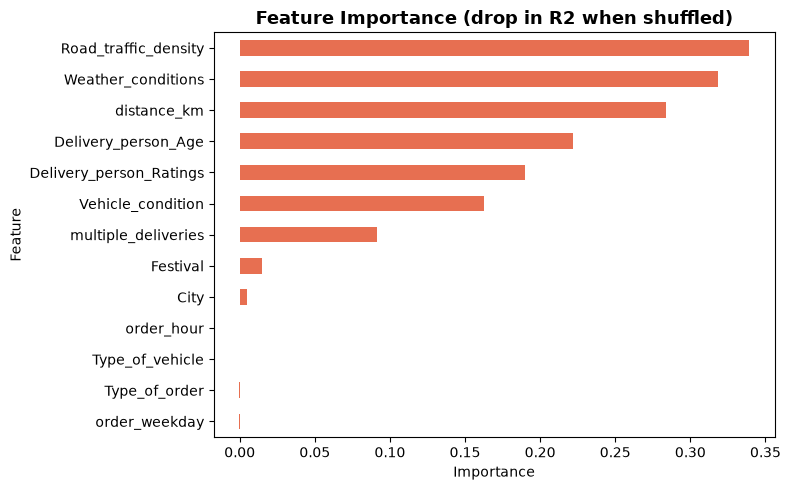

Top 3 drivers: ['Road_traffic_density', 'Weather_conditions', 'distance_km']


In [56]:
# Permutation importance works for any model and reports importance per ORIGINAL column
from sklearn.inspection import permutation_importance

sample_idx = X_test.sample(min(2000, len(X_test)), random_state=42).index
perm = permutation_importance(best, X_test.loc[sample_idx], y_test.loc[sample_idx],
                              n_repeats=5, random_state=42, n_jobs=-1, scoring="r2")
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(8, 5))
imp.plot(kind="barh", color="#e76f51")
plt.title("Feature Importance (drop in R2 when shuffled)", fontsize=13, weight="bold")
plt.xlabel("Importance"); plt.ylabel("Feature")
plt.tight_layout(); plt.savefig("charts/chart6_feature_importance.png", dpi=150); plt.show()
print("Top 3 drivers:", list(imp.sort_values(ascending=False).head(3).index))

In [57]:
# What-if analysis: same order, only the traffic level changes
base = X_test.iloc[[0]]
scenarios = []
for t in traffic_order:
    r = base.copy()
    r["Road_traffic_density"] = t
    scenarios.append(r)
whatif = pd.concat(scenarios)
whatif["predicted_time_min"] = best.predict(whatif).round(1)
whatif[["Road_traffic_density", "distance_km", "Weather_conditions", "predicted_time_min"]]

,Road_traffic_density,distance_km,Weather_conditions,predicted_time_min
38097,Low,12.350686,Sunny,26.4
38097,Medium,12.350686,Sunny,16.6
38097,High,12.350686,Sunny,17.1
38097,Jam,12.350686,Sunny,17.4


In [58]:
ml_summary = {
    "best_model": best_name,
    "test_MAE_min": round(float(results.loc[best_name, "MAE (min)"]), 2),
    "test_R2": round(float(results.loc[best_name, "R2"]), 3),
    "top_drivers": list(imp.sort_values(ascending=False).head(3).index),
}
print(ml_summary)
print("\nInterpretation: the model predicts delivery time within about "
      f"{ml_summary['test_MAE_min']} minutes on average; the top drivers are {ml_summary['top_drivers']}.")

{'best_model': 'Gradient Boosting', 'test_MAE_min': 3.06, 'test_R2': 0.829, 'top_drivers': ['Road_traffic_density', 'Weather_conditions', 'distance_km']}

Interpretation: the model predicts delivery time within about 3.06 minutes on average; the top drivers are ['Road_traffic_density', 'Weather_conditions', 'distance_km'].
